# Section 0 — Imports & setup

- Mount Drive, import libraries
- Load `llm_results`, `nlp_results` pickles
- Define `EMOTIONS`, `TASTES`, constants
- Download Kaggle dataset, build `image_lookup`

In [1]:
import os, pickle, glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

from scipy.stats import spearmanr, wilcoxon

from google.colab import drive
drive.mount('/content/drive')

print('All imports OK')

Mounted at /content/drive
All imports OK


In [2]:
# Label lists
EMOTIONS = [
    'Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied',
    'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy'
]
TASTES = ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']

EMOTIONS_LOWER = [e.lower() for e in EMOTIONS]
TASTES_LOWER   = [t.lower() for t in TASTES]
N_BOOKS        = 60

print(f'Emotions ({len(EMOTIONS)}): {EMOTIONS}')
print(f'Tastes   ({len(TASTES)}):   {TASTES}')


Emotions (12): ['Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied', 'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy']
Tastes   (5):   ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']


In [3]:
# Load CLIP / NLP results
with open('/content/drive/MyDrive/dataset/llm_rankings.pkl', 'rb') as f:
    llm_results = pickle.load(f)
with open('/content/drive/MyDrive/dataset/nlp_rankings.pkl', 'rb') as f:
    nlp_results = pickle.load(f)

print('LLM emotions:', list(llm_results['emotion'].keys()))
print('LLM tastes:  ', list(llm_results['taste'].keys()))

# Kaggle image lookup (ISBN filename → Kaggle cache path)
import kagglehub
dataset_path = kagglehub.dataset_download('mexwell/book-cover-dataset')
all_kaggle = (
    glob.glob(os.path.join(dataset_path, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.png'),  recursive=True)
)
image_lookup = {os.path.basename(p): p for p in all_kaggle}
print(f'Kaggle images indexed: {len(image_lookup):,}')

LLM emotions: ['happy', 'pleasure', 'astonished', 'relaxed', 'satisfied', 'tired', 'fear', 'angry', 'annoyed', 'sad', 'disgust', 'droopy']
LLM tastes:   ['sweet', 'sour', 'salty', 'bitter', 'umami']


100%|██████████| 675M/675M [00:04<00:00, 160MB/s]

Extracting files...


Kaggle images indexed: 57,000


# Section 1 — NLP vs CLIP agreement (Spearman)

- Spearman correlation function + compute for emotion & taste
- Bar chart visualisation
- Summary stats printout

In [4]:
def compute_spearman(nlp_rankings, llm_rankings):
    results = []

    for label, nlp_data in nlp_rankings.items():
        if label not in llm_rankings:
            continue

        llm_data = llm_rankings[label]

        # Pre-calculate rank positions using dictionary (much faster than using nested for loops)
        # This maps: {'filename': rank_position}
        nlp_map = {fname: i + 1 for i, (fname, _) in enumerate(nlp_data)}
        llm_map = {fname: i + 1 for i, (fname, _) in enumerate(llm_data)}

        # Find common books using Set intersection
        common = set(nlp_map.keys()).intersection(llm_map.keys())

        if len(common) < 3:
            continue

        # Extract ranks only for common books
        # We convert to a list to ensure the order is identical for both arrays
        common_list = list(common)
        nlp_ranks = [nlp_map[b] for b in common_list]
        llm_ranks = [llm_map[b] for b in common_list]

        # Compute correlation
        rho, pval = spearmanr(nlp_ranks, llm_ranks)

        results.append({
            'Label': label,
            'Spearman ρ': round(rho, 4),
            'p-value': round(pval, 4),
            'Significant': '✓' if pval < 0.001 else '✗',
            'N books': len(common)
        })

    return pd.DataFrame(results).set_index('Label')

# Run the faster version
emotion_spearman = compute_spearman(nlp_results['emotion'], llm_results['emotion'])
taste_spearman   = compute_spearman(nlp_results['taste'],   llm_results['taste'])

print('Emotion:\n', emotion_spearman.to_string())
print('\nTaste:\n',  taste_spearman.to_string())

Emotion:
            Spearman ρ  p-value Significant  N books
Label                                              
happy          0.9117      0.0           ✓    56167
pleasure       0.9434      0.0           ✓    56167
relaxed        0.9166      0.0           ✓    56167
satisfied      0.8683      0.0           ✓    56167
tired          0.7746      0.0           ✓    56167
fear           0.8794      0.0           ✓    56167
angry          0.8812      0.0           ✓    56167
annoyed        0.9215      0.0           ✓    56167
sad            0.9277      0.0           ✓    56167
disgust        0.8605      0.0           ✓    56167
droopy         0.9239      0.0           ✓    56167

Taste:
         Spearman ρ  p-value Significant  N books
Label                                           
sweet       0.7496      0.0           ✓    56167
sour        0.9079      0.0           ✓    56167
salty       0.7596      0.0           ✓    56167
bitter      0.6453      0.0           ✓    56167
umami      

In [5]:
# Quick fix: standardize the misspelled key if it exists
if 'asthonished' in nlp_results['emotion']:
    nlp_results['emotion']['astonished'] = nlp_results['emotion'].pop('asthonished')

if 'asthonished' in llm_results['emotion']:
    llm_results['emotion']['astonished'] = llm_results['emotion'].pop('asthonished')

# Then run the Spearman calculation
emotion_spearman = compute_spearman(nlp_results['emotion'], llm_results['emotion'])

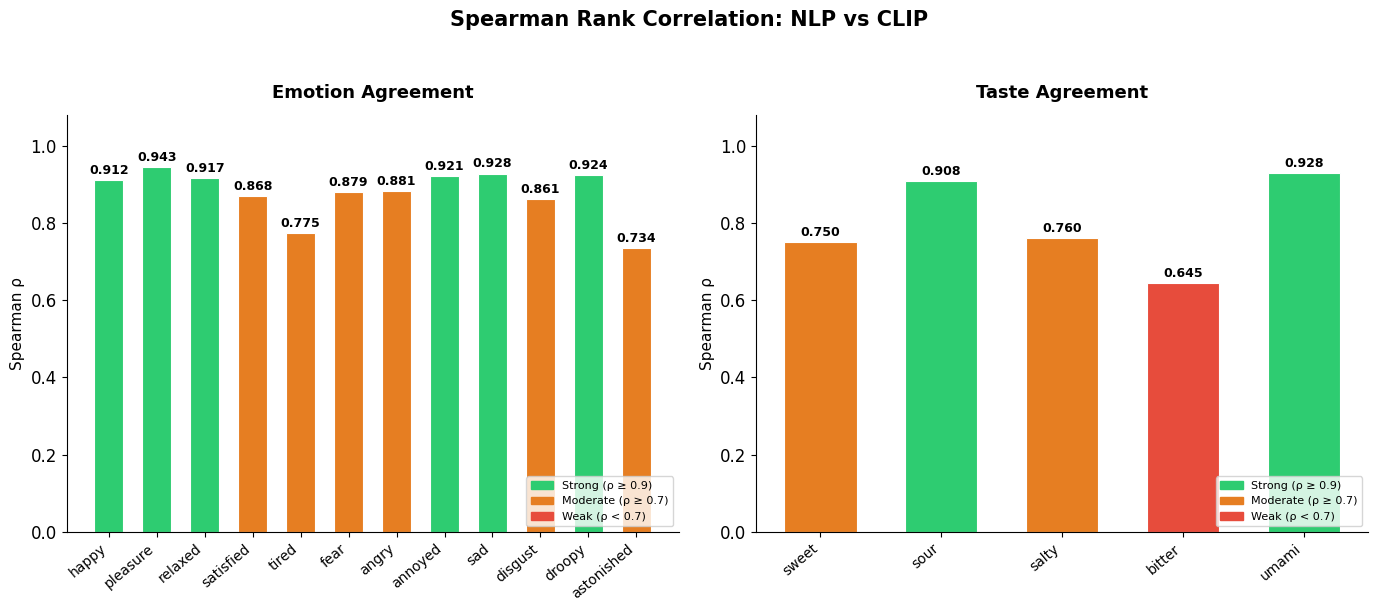

Emotion: mean=0.8786  max=0.9434 (pleasure)  sig=12/12
Taste: mean=0.7981  max=0.9280 (umami)  sig=5/5


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (df, title) in zip(axes, [(emotion_spearman, 'Emotion Agreement'),
                                   (taste_spearman,   'Taste Agreement')]):
    rhos   = df['Spearman ρ'].values
    colors = ['#2ecc71' if r>=0.9 else '#e67e22' if r>=0.7 else '#e74c3c' for r in rhos]
    bars   = ax.bar(range(len(rhos)), rhos, color=colors, width=0.6,
                    edgecolor='white', linewidth=0.8)
    for bar, rho in zip(bars, rhos):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{rho:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(rhos)))
    ax.set_xticklabels(df.index, rotation=40, ha='right', fontsize=10)
    ax.set_ylim(0, 1.08); ax.set_ylabel('Spearman ρ', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13, pad=12)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(handles=[
        mpatches.Patch(color='#2ecc71', label='Strong (ρ ≥ 0.9)'),
        mpatches.Patch(color='#e67e22', label='Moderate (ρ ≥ 0.7)'),
        mpatches.Patch(color='#e74c3c', label='Weak (ρ < 0.7)'),
    ], fontsize=8, loc='lower right')
fig.suptitle('Spearman Rank Correlation: NLP vs CLIP', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

for name, df in [('Emotion', emotion_spearman), ('Taste', taste_spearman)]:
    rhos = df['Spearman ρ']
    print(f'{name}: mean={rhos.mean():.4f}  max={rhos.max():.4f} ({rhos.idxmax()})  '
          f'sig={(df["p-value"]<0.05).sum()}/{len(df)}')


# Section 2 — NLP vs CLIP agreement (Wilcoxon Signed-Rank test)
This tests whether there is a statistically significant DIFFERENCE between the rank positions assigned by the NLP and LLM prototypes for each emotion/taste category.

- H0: No significant difference between NLP and LLM ranks
- H1: There IS a significant difference between NLP and LLM ranks

In [10]:
def compute_wilcoxon(nlp_rankings, llm_rankings):
    results = []

    for label, nlp_data in nlp_rankings.items():
        if label not in llm_rankings:
            continue

        llm_data = llm_rankings[label]

        # Map: {filename: rank_position}
        nlp_map = {fname: i + 1 for i, (fname, _) in enumerate(nlp_data)}
        llm_map = {fname: i + 1 for i, (fname, _) in enumerate(llm_data)}

        # Find common books
        common = sorted(set(nlp_map.keys()).intersection(llm_map.keys()))

        if len(common) < 10:
            # Wilcoxon needs a reasonable sample size
            continue

        # Extract paired ranks
        nlp_ranks = np.array([nlp_map[b] for b in common])
        llm_ranks = np.array([llm_map[b] for b in common])

        # Compute differences
        diffs = nlp_ranks - llm_ranks

        # Skip if all differences are zero (Wilcoxon can't handle this)
        if np.all(diffs == 0):
            results.append({
                'Label': label,
                'W statistic': np.nan,
                'p-value': 1.0,
                'Significant': 'X (identical)',
                'N books': len(common),
                'Mean |diff|': 0.0,
                'Median diff': 0.0
            })
            continue

        # Wilcoxon signed-rank test (two-sided)
        stat, pval = wilcoxon(nlp_ranks, llm_ranks)

        results.append({
            'Label': label,
            'W statistic': round(stat, 2),
            'p-value': pval,
            'Significant': '/ (diff)' if pval < 0.05 else 'X (no diff)',
            'N books': len(common),
            'Mean |diff|': round(np.mean(np.abs(diffs)), 2),
            'Median diff': round(np.median(diffs), 2)
        })

    df = pd.DataFrame(results).set_index('Label')
    return df


In [14]:
emotion_wilcoxon = compute_wilcoxon(nlp_results['emotion'], llm_results['emotion'])
taste_wilcoxon   = compute_wilcoxon(nlp_results['taste'],   llm_results['taste'])

print('Emotion Wilcoxon Signed-Rank Test:\n', emotion_wilcoxon.to_string())
print('\nTaste Wilcoxon Signed-Rank Test:\n',  taste_wilcoxon.to_string())

Emotion Wilcoxon Signed-Rank Test:
             W statistic       p-value  Significant  N books  Mean |diff|  Median diff
Label                                                                                
happy       777288446.5  3.686422e-03     / (diff)    56167      5085.69         99.0
pleasure    779253729.0  1.741756e-02     / (diff)    56167      4077.24         63.0
relaxed     782948682.5  1.424217e-01  X (no diff)    56167      4989.35         47.0
satisfied   784924607.5  3.445097e-01  X (no diff)    56167      6265.01         42.0
tired       772074477.5  1.622590e-05     / (diff)    56167      8228.74       -230.0
fear        783482062.0  1.865878e-01  X (no diff)    56167      6014.14        -22.0
angry       768996572.5  3.992127e-07     / (diff)    56167      5922.56       -149.0
annoyed     787767597.5  8.659276e-01  X (no diff)    56167      4784.51        -13.0
sad         785840092.5  5.118332e-01  X (no diff)    56167      4578.75         29.0
disgust     778013

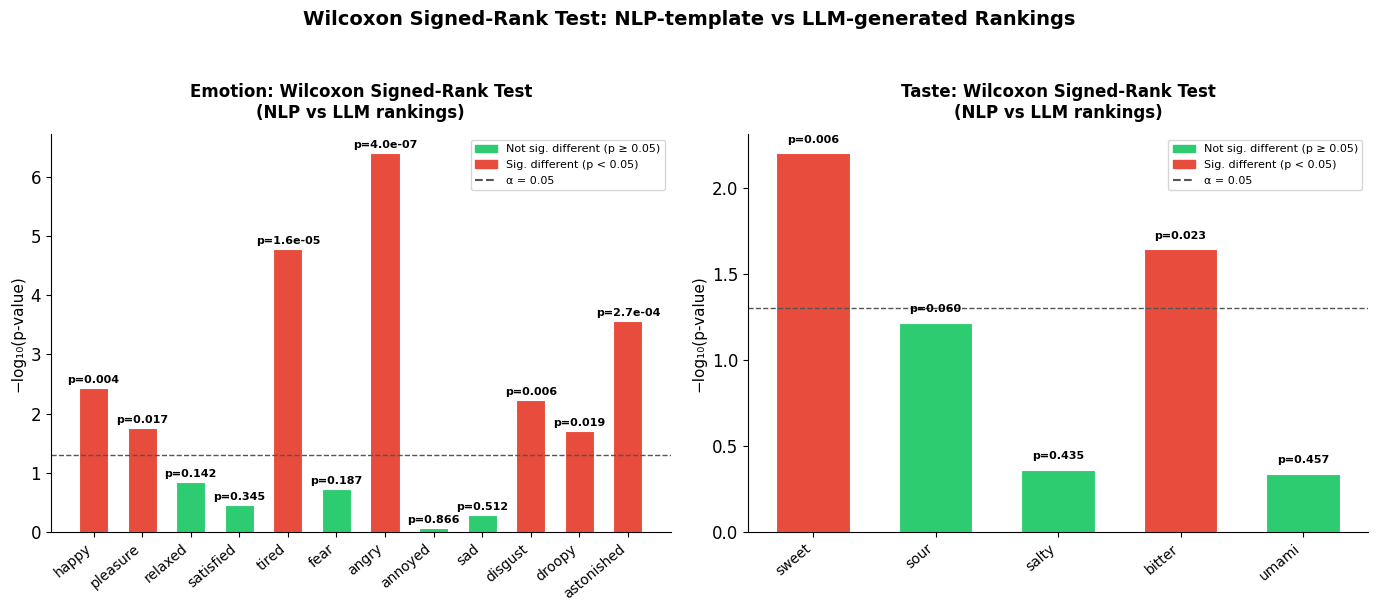

In [17]:
# Visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df, title) in zip(axes, [(emotion_wilcoxon, 'Emotion'),
                                   (taste_wilcoxon,   'Taste')]):

    labels = df.index.tolist()
    pvals  = df['p-value'].values

    # Colour code: green = NOT significantly different (good — methods agree)
    #              red   = significantly different (methods disagree)
    colors = ['#e74c3c' if p < 0.05 else '#2ecc71' for p in pvals]

    # Plot -log10(p) so smaller p-values produce taller bars
    neg_log_p = -np.log10(pvals + 1e-300)  # add epsilon to avoid log(0)

    bars = ax.bar(range(len(labels)), neg_log_p, color=colors, width=0.6,
                  edgecolor='white', linewidth=0.8)

    # Add p-value text on top of each bar
    for bar, p in zip(bars, pvals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'p={p:.3f}' if p >= 0.001 else f'p={p:.1e}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Significance threshold line at -log10(0.05) ≈ 1.301
    ax.axhline(-np.log10(0.05), color='#555', linestyle='--', linewidth=1,
               label='α = 0.05 threshold')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    ax.set_ylabel('−log₁₀(p-value)', fontsize=11)
    ax.set_title(f'{title}: Wilcoxon Signed-Rank Test\n(NLP vs LLM rankings)',
                 fontweight='bold', fontsize=12, pad=12)
    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(handles=[
        mpatches.Patch(color='#2ecc71', label='Not sig. different (p ≥ 0.05)'),
        mpatches.Patch(color='#e74c3c', label='Sig. different (p < 0.05)'),
        plt.Line2D([0], [0], color='#555', linestyle='--', label='α = 0.05'),
    ], fontsize=8, loc='upper right')

fig.suptitle('Wilcoxon Signed-Rank Test: NLP-template vs LLM-generated Rankings',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wilcoxon_nlp_vs_llm.pdf', bbox_inches='tight')
plt.show()

In [16]:
for name, df in [('Emotion', emotion_wilcoxon), ('Taste', taste_wilcoxon)]:
    n_sig = (df['p-value'] < 0.05).sum()
    n_total = len(df)
    print(f'\n{name}: {n_sig}/{n_total} categories show significant differences '
          f'between NLP and LLM rankings.')
    if n_sig == 0:
        print(f'The two description methods produce rankings that are '
              f'NOT significantly different for any {name.lower()} category.')
    else:
        sig_labels = df[df['p-value'] < 0.05].index.tolist()
        print(f'Significant differences found in: {", ".join(sig_labels)}')


Emotion: 7/12 categories show significant differences between NLP and LLM rankings.
Significant differences found in: happy, pleasure, tired, angry, disgust, droopy, astonished

Taste: 2/5 categories show significant differences between NLP and LLM rankings.
Significant differences found in: sweet, bitter
